In [27]:
#경고 무시용 모듈 사용
import warnings as wr
wr.filterwarnings(action='ignore')
#외부 url의 결과를 받아오기 위한 모듈 
import requests

<h1 id="%EB%8D%B0%EC%9D%B4%ED%84%B0-%EC%88%98%EC%A7%91%EC%9D%84-%EC%9C%84%ED%95%9C-python-%EB%B3%B5%EC%8A%B5">데이터 수집을 위한 python 복습¶</h1>
find() , index() 차이
len() , strip() , replace()
정규표현식 (Regular expressions)

In [28]:
text ="<title>ICTStudy 빅데이터 수집</title>"
#python에서 문자열 함수 : index, find 차이?
#빅이란 단어의 위치를 찾기 
print(f"index로 찾기 =>{text.index('빅')}")
print(f"find로 찾기 => {text.find('빅')}")

index로 찾기 =>16
find로 찾기 => 16


In [29]:
# 존재하지 않는 단어의 위치를 찾고자 할 경우
print(f"find로 찾기 => {text.find('박')}")
#print(f"index로 찾기 =>{text.index('박')}") #ValueError

find로 찾기 => -1


In [30]:
#index일 경우에는 검색 단어가 없을 경우 ValueError 예외가 발생
searchValue='와'
try:
    print(f"index로 찾기 =>{text.index(searchValue)}")
    print(f"찾은 단어를 검색했습니다.")
except ValueError:
    print(f"해당 단어:\"{searchValue}\"는(은) 존재하지 않습니다.")

해당 단어:"와"는(은) 존재하지 않습니다.


In [31]:
# 문자열에서 공백을 제거하는 함수 
# rstrip() ,lstrip(), strip(): 오른쪽, 왼쪽 , 양쪽 공백 제거
text2 =" <title>ICTStudy 빅데이터 수집</title> "
print(f"text2 문자열의 길이 :{len(text2)}")
print(f'text2 rstrip(): {len(text2.rstrip())}')

text2 문자열의 길이 :33
text2 rstrip(): 32


In [32]:
text2.rstrip() , text2.lstrip() , text2.strip()

(' <title>ICTStudy 빅데이터 수집</title>',
 '<title>ICTStudy 빅데이터 수집</title> ',
 '<title>ICTStudy 빅데이터 수집</title>')

In [33]:
# 문자열 변경 
# 특정 단어를 변경 
text3 ="<title>ICTStudy 빅데이터 수집</title>"
text_rep = text3.replace('title','div')
text_rep

'<div>ICTStudy 빅데이터 수집</div>'

In [34]:
import re

In [35]:
text = ('111<head>안녕하세요</head>22')
text

'111<head>안녕하세요</head>22'

In [36]:
# re.search('정규표현식추출',문자열) : <re.Match object 
#정규 표현식의 .(dot) 메타 문자는 줄바꿈 문자인 \n을 제외한 모든 문자와 매치된다는 것을 의미한다.
body = re.search(r'<head.',text)
print(f"search => {body} , type(body) => {type(body)}")
print(f"body.group() => {type(body.group())}")
body_gr1 = body.group()
print(f"추출한 데이터 => {body_gr1}")

search => <re.Match object; span=(3, 9), match='<head>'> , type(body) => <class 're.Match'>
body.group() => <class 'str'>
추출한 데이터 => <head>


In [37]:
#'111<head>안녕하세요</head>22'
#우리가 원하는 것은 태그와 태그 사이 
body1 = re.search(r'<head.*/head>',text)
body_gr2 = body1.group()
print(f"추출한 데이터 => {body_gr2}")

추출한 데이터 => <head>안녕하세요</head>


In [38]:
# 한번 해보기 1-> 태그 안에 태그를 정규표현식으로 가져오기 
# 결과 => <title> ICT01 협회 데이터 수집 개발 </title>
text = ('<head> 안녕하세요... <title> ICT01 협회 데이터 수집 개발 </title> 반갑습니다.....</head>')
body = re.search(r'<title.*/title>',text)
body_res = body.group()
print(body_res)

<title> ICT01 협회 데이터 수집 개발 </title>


In [39]:
# 정규표현식 re.sub(정규표현식,'변경',str)
# +는 최소 1번 이상 반복될 때 사용
# ? 메타 문자가 의미하는 것은 {0, 1}
# ab?c => "a + b가 있어도 되고 없어도 됨 + c"
# '<.+?>' 
# body_res는 string
# tag를 삭제하자
body_res2 = re.sub('<.+?>','',body_res)
print(body_res2.strip())

ICT01 협회 데이터 수집 개발


In [40]:
#re.findall()
text = "점수: 90, 85, 100"
scores = re.findall("\d+", text)
print(scores)

['90', '85', '100']


<h2 id="1.-%EC%9B%B9-%EC%8A%A4%ED%81%AC%EB%9E%98%ED%95%91-(Web-Scraping)">1. 웹 스크래핑 (Web Scraping)¶</h2><p>웹 사이트 상에서 원하는 부분에 위치한 정보를 추출하여 수집하는 기술이다.
특정 페이지의 HTML 문서 소스 중에서 필요한 데이터만 골라내는 작업을 말한다.</p>
<h2 id="2.-BeautifulSoup">2. BeautifulSoup¶</h2><p>파이썬의 대표적인 스크래핑 라이브러리 이다.
HTML 및 XML 문서를 구조화하여 데이터를 쉽게 추출할 수 있도록 한다.</p>
<h2 id="3.-%ED%8C%8C%EC%84%9C(Parser)%EC%9D%98-%EC%A2%85%EB%A5%98">3. 파서(Parser)의 종류¶</h2><p>BeautifulSoup은 HTML을 분석하기 위해 아래와 같은 파서들을 사용.</p>
<p>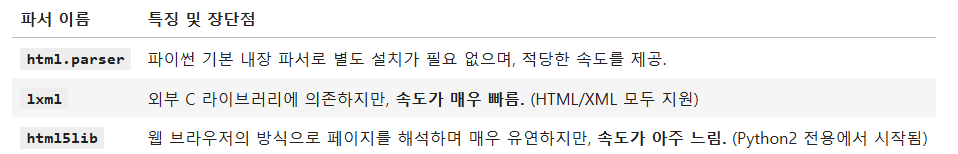</p>
<h2 id="4.-%EC%9B%B9-%ED%81%AC%EB%A1%A4%EB%A7%81-(Web-Crawling)">4. 웹 크롤링 (Web Crawling)¶</h2><p>자동화 봇인 웹 크롤러(Web Crawler)가 정해진 규칙에 따라 복수 개의 웹 페이지를 브라우징하는 작업이다.
스크래핑이 '추출'에 중점을 둔다면, 크롤링은 페이지 사이를 이동하는 '탐색'에 중점을 둔다.</p>

In [41]:
#!pip list | grep beautiful

In [42]:
#!pip install lxml

In [43]:
#!pip install --upgrade pip

In [44]:
#!pip list | grep lxml

In [45]:
# 가상 데이터
html = """
<html>
    <body>
        <h1>나의 첫번째 웹스크래핑</h1>
        <p>첫번째 라인</p>
        <p>두번째 라인</p>
        <p><b>여기를 출력하시요.</b></p>
    </body>
</html>
"""

In [46]:
from bs4 import BeautifulSoup

In [47]:
#BeautifulSoup(data,'html.parser') 
soup = BeautifulSoup(html,'html.parser')
print(type(soup))
print(soup)

<class 'bs4.BeautifulSoup'>

<html>
<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>
</html>



가장 단순하게 . 연산자를 사용해서 Document Object 주소로 접근하는 방법

In [48]:
h1v = soup.html.body.h1
print(h1v,type(h1v))

<h1>나의 첫번째 웹스크래핑</h1> <class 'bs4.element.Tag'>


In [49]:
# type
print(f"soup.html {type(soup.html)}") #bs4.element.Tag
print(f"soup.html {type(soup.html.body)}") #bs4.element.Tag
print(f"soup.html {type(soup.html.body.h1)}") #bs4.element.Tag

soup.html <class 'bs4.element.Tag'>
soup.html <class 'bs4.element.Tag'>
soup.html <class 'bs4.element.Tag'>


In [50]:
# get_text() : Tag 객체가 가지고 있는 메서드인 get_text()
# tag안에 text만 추출 
print(h1v.get_text())
print(f"Tag.get_text()의 type => {type(h1v.get_text())}")
#예) 문자열이면 여기부터는 문자열 함수를 사용가능 =>
h1v.get_text().split()

나의 첫번째 웹스크래핑
Tag.get_text()의 type => <class 'str'>


['나의', '첫번째', '웹스크래핑']

In [51]:
#<p>첫번째 라인</p> 변수 p1에 저장한 후 출력 해보기
p1 = soup.html.body.p
print(p1)
print(p1.get_text())

<p>첫번째 라인</p>
첫번째 라인


In [52]:
# parent soup의 커서를 부모로 이동한다. 
hp1 = h1v.parent
print(type(hp1))
print('*'*30)
print(hp1)

<class 'bs4.element.Tag'>
******************************
<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>


In [53]:
#상위 부모들을 모두 가져온다. 이런게 있다.
hp2 = h1v.parents
print(hp2)
print(type(hp2)) ##generator  그때 테스트 다 햇음 -> list
print(list(hp2))

<generator object PageElement.parents at 0x00000296F3D0B440>
<class 'generator'>
[<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>, <html>
<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>
</html>, 
<html>
<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>
</html>
]


In [54]:
# 가상 데이터
html = """<html>
    <body>
        <h1>나의 첫번째 웹스크래핑</h1>
        <p>첫번째 라인</p>
        <p>두번째 라인</p>
        <p><b>여기를 출력하시오.</b></p>
    </body>
</html>"""
#body,html,soup 기준으로 리스트로 저장됨
h1v = soup.html.body.h1
print(h1v,type(h1v))
#상위 부모들을 모두 가져온다. 이런게 있다.
hp3 = h1v.parents
print(hp3)
print(type(hp3))
print(list(hp3))

<h1>나의 첫번째 웹스크래핑</h1> <class 'bs4.element.Tag'>
<generator object PageElement.parents at 0x00000296F3DE8AD0>
<class 'generator'>
[<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>, <html>
<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>
</html>, 
<html>
<body>
<h1>나의 첫번째 웹스크래핑</h1>
<p>첫번째 라인</p>
<p>두번째 라인</p>
<p><b>여기를 출력하시요.</b></p>
</body>
</html>
]


In [55]:
p1

<p>첫번째 라인</p>

In [56]:
#Tag.previous_sibling : 인접요소의  속성값 다음에 바로 출력된다.
# 공백일 경우 : dom의 요소로 포함 -> NavigableString
space1 = p1.previous_sibling
print(f'previous_sibling : {space1} , type : {type(space1)}')

previous_sibling : 
 , type : <class 'bs4.element.NavigableString'>


In [57]:
#previous_element , next_element
# 공백<p>첫번째 라인</p>
print('previous_element :',p1.previous_element)
print(f'next_element : {p1.next_element}')

previous_element : 

next_element : 첫번째 라인


In [58]:
# next_sibling사용해서 2번 사용해서 바로 옆에 있는 두번째 요소에 접근 하는 방식
p2 = p1.next_sibling.next_sibling
print(p2,":",type(p2))

<p>두번째 라인</p> : <class 'bs4.element.Tag'>


In [59]:
# 한번 해보기 
# 변수 soup의 예문에서 "여기를 출력하세요." 를 출력하시오. 
# 위의 코드 p2에서 다시 next_sibling을 사용해서 접근한 후 
# "여기를 출력하시오." -> 출력결과
#soup ,Tag객체에서 get_text
print(p2 , type(p2))
p3 = p2.next_sibling.next_sibling
print(type(p3))
print(p3.get_text(),":",type(p3.get_text()))
print(p3.text,":",type(p3.text))

<p>두번째 라인</p> <class 'bs4.element.Tag'>
<class 'bs4.element.Tag'>
여기를 출력하시요. : <class 'str'>
여기를 출력하시요. : <class 'str'>


<p>https://search.kyobobook.co.kr/search?keyword=python&target=total&gbCode=TOT&page=2</p>

<p>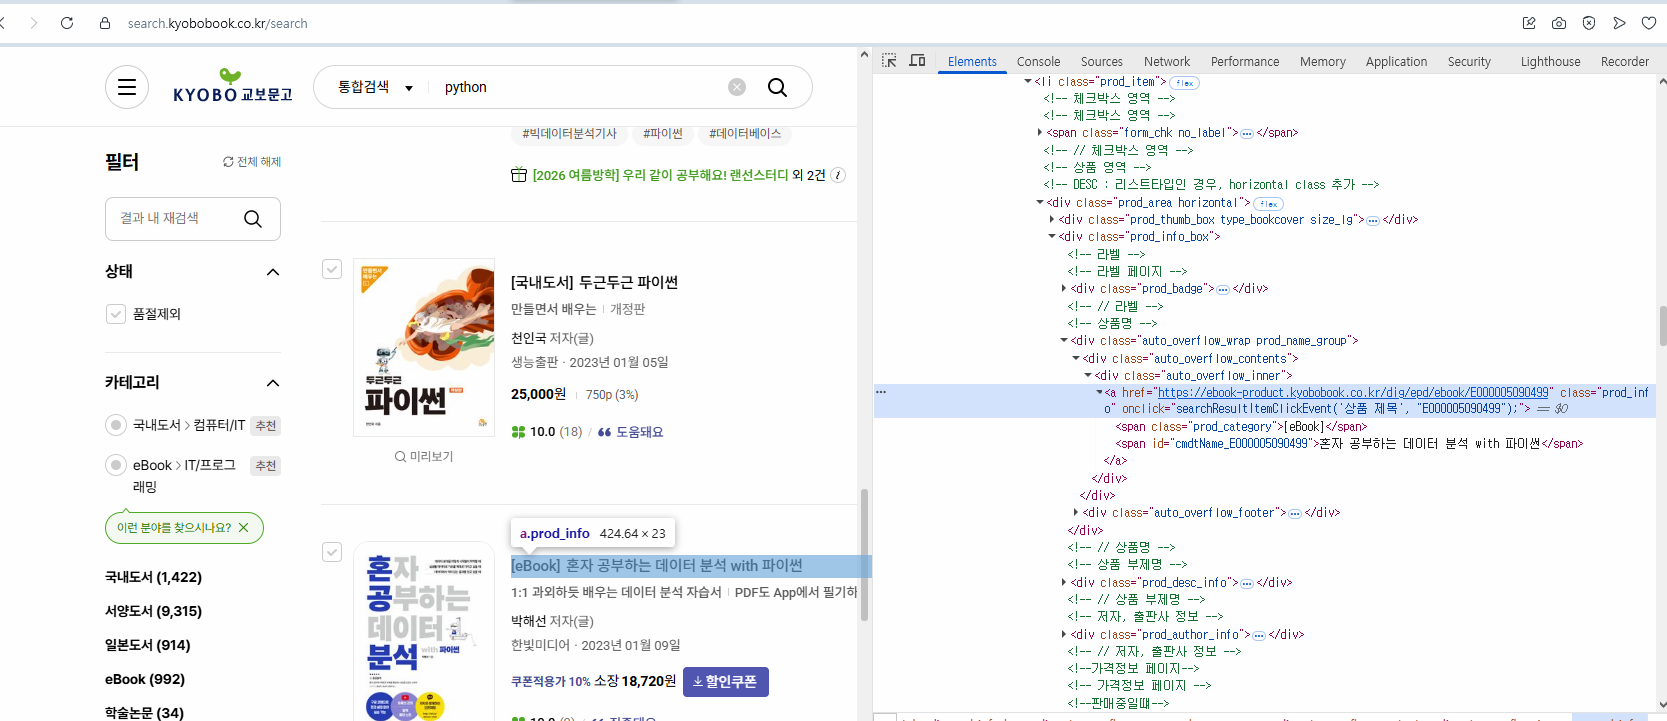</p>

In [60]:
#!pip install tqdm

In [61]:
import math
from tqdm import tqdm

In [62]:
searchName='python'
pageNum=1

In [63]:
# 교보문고의 url 에서 searchName, page 값을 변수 처리한다.
url = f"https://search.kyobobook.co.kr/search?keyword={searchName}&target=total&gbCode=TOT&page={pageNum}"

In [64]:
# reqests.get() 사용해서 서버에 접속후 데이터를 받아온다.
res = requests.get(url)
#res.text[:1000]
# 받아온 데이터를 가공 처리하기 위해서 BeautifulSoup() 을 생성한다.
soup = BeautifulSoup(res.text,'html.parser')

<h2 id="find,-findAll-%ED%95%99%EC%8A%B5">find, findAll 학습¶</h2>

In [65]:
html2='''
<html>
    <body>
    <h1 id="title"> Hello Python</h1>
    <p id="body"> 웹 스크래핑 분석 </p>
    <p class="scp">웹 스크래핑 1</p>
    <p class="scp">웹 스크래핑 2</p>
    <p class="scp">웹 스크래핑 3</p>
    <div class="scp">*웹 스크래핑 3</div>
    <span class="scp">여기는 출력안 시킬 요소</span>
    </body>
</html>
'''
soup = BeautifulSoup(html2,'html.parser')
scnt = soup.contents
print(f'contents => {scnt}')
print(len(' 웹 스크래핑 분석 '))

contents => ['\n', <html>
<body>
<h1 id="title"> Hello Python</h1>
<p id="body"> 웹 스크래핑 분석 </p>
<p class="scp">웹 스크래핑 1</p>
<p class="scp">웹 스크래핑 2</p>
<p class="scp">웹 스크래핑 3</p>
<div class="scp">*웹 스크래핑 3</div>
<span class="scp">여기는 출력안 시킬 요소</span>
</body>
</html>, '\n']
11


In [66]:
#stripped_strings : string으로 반환 하면서 공백도 함께 제거 , 
#태그도 제거 됨
for e in soup.stripped_strings:
    print(f"{e} => len : {len(e)}")

Hello Python => len : 12
웹 스크래핑 분석 => len : 9
웹 스크래핑 1 => len : 8
웹 스크래핑 2 => len : 8
웹 스크래핑 3 => len : 8
*웹 스크래핑 3 => len : 9
여기는 출력안 시킬 요소 => len : 13


In [67]:
# 한번 해보기 stripped_strings 해서 h1의 값을 아래의 결과처럼 출력 하시오.
# 출력결과 => ['Hello Python']
print(type(soup.html.body.h1))
list(soup.html.body.h1.stripped_strings)  #<generator object

<class 'bs4.element.Tag'>


['Hello Python']

<h3 id="find('%EC%9A%94%EC%86%8C')-:-%ED%95%98%EB%82%98%EC%9D%98-%EC%9A%94%EC%86%8C%EB%A5%BC-%EC%B0%BE%EA%B8%B0-*****">find('요소') : 하나의 요소를 찾기 *****¶</h3>

In [68]:
h1tag = soup.find('h1')
h1tag , type(h1tag)

(<h1 id="title"> Hello Python</h1>, bs4.element.Tag)

In [69]:
#Element Name
print(f"Element Name : {h1tag.name}")

Element Name : h1


In [70]:
# 속성 : attrs =>딕셔너리로 반환 
#h1tag => <h1 id="title"> Hello Python</h1>
print(f"Tag Attrs : {h1tag.attrs}")

Tag Attrs : {'id': 'title'}


In [71]:
# tag 속성 중 id만 출력하겠다.
# soup.attrs['속성']
print(f"Tag Attrs[Key] : {h1tag.attrs['id']}")

Tag Attrs[Key] : title


In [72]:
# find 는 오직 집합에서 배열의 첫번째만 가져온다.
# 여러개의 요소가 존재할 경우에 findAll
# 지금 예제에서 p경우 
#soup

In [73]:
p1tag = soup.find('p')
print(p1tag)

<p id="body"> 웹 스크래핑 분석 </p>


In [74]:
#soup.find(class_='클래스')
#find를 사용해서 class속성으로 찾기 
"""
<p class="scp">웹 스크래핑 1</p>
<p class="scp">웹 스크래핑 2</p>
<p class="scp">웹 스크래핑 3</p>
"""
p1clastag = soup.find(class_='scp')
p1clastag

<p class="scp">웹 스크래핑 1</p>

In [75]:
p1clasMap = soup.find('div',{'class':'scp'})
p1clasMap

<div class="scp">*웹 스크래핑 3</div>

In [76]:
# find : id 속성을 사용하는 방법
titlev = soup.find(id='title')
bodyv = soup.find(id='body')
print(f"title => {titlev.string} , type => {type(titlev.string)}")
print(f"body => {bodyv.string} , {bodyv.text}")

title =>  Hello Python , type => <class 'bs4.element.NavigableString'>
body =>  웹 스크래핑 분석  ,  웹 스크래핑 분석 


In [77]:
# 집합 요소 추출하기 : find_all -> 리스트 반환 
# class 를 map 방식으로 사용 
"""
    <p class="scp">웹 스크래핑 1</p>
    <p class="scp">웹 스크래핑 2</p>
    <p class="scp">웹 스크래핑 3</p>
    <div class="scp">*웹 스크래핑 3</div>
    <span class="scp">여기는 출력안 시킬 요소</span>
"""
#f_all = soup.find_all('p',{'class':'scp'})
#f_all
f_all = soup.find_all(['p','div'],{'class':'scp'})
f_all

[<p class="scp">웹 스크래핑 1</p>,
 <p class="scp">웹 스크래핑 2</p>,
 <p class="scp">웹 스크래핑 3</p>,
 <div class="scp">*웹 스크래핑 3</div>]

In [78]:
print(f'find_all 메서드의 반환 타입 : {type(f_all)}')

find_all 메서드의 반환 타입 : <class 'bs4.element.ResultSet'>


In [79]:
for e in f_all:
    print(f"e => {type(e)} : {e} : {e.text}")

e => <class 'bs4.element.Tag'> : <p class="scp">웹 스크래핑 1</p> : 웹 스크래핑 1
e => <class 'bs4.element.Tag'> : <p class="scp">웹 스크래핑 2</p> : 웹 스크래핑 2
e => <class 'bs4.element.Tag'> : <p class="scp">웹 스크래핑 3</p> : 웹 스크래핑 3
e => <class 'bs4.element.Tag'> : <div class="scp">*웹 스크래핑 3</div> : *웹 스크래핑 3


In [80]:
# BeautifulSoup 모듈을 사용해서 속성 다루기 
# 연습문제) find,find_all 사용해서 데이터 추출하기 
# https://cafe.daum.net/icteduAI/MZa4/92
html3='''
<html>
    <body>
    <div class="tag1">
        <h1 id="title1"> Hello Python</h1>
        <p id="body1"> 웹 스크래핑 분석 </p>
        <p class="scp">웹 스크래핑 1</p>
        <p class="scp">웹 스크래핑 2</p>
        <p class="scp">웹 스크래핑 3</p>
    </div>
    <div class="tag1 target">
        <h1 id="title2"> Hello Python2</h1>
        <p id="body2"> 웹 스크래핑 분석 2</p>
        <p class="scp">웹 target 스크래핑 1</p>
        <p class="scp">웹 target 스크래핑 2</p>
        <p class="scp">웹 target 스크래핑 3</p>
    </div>
    <div>
        <a href="">Test</a>
    </div>
    </body>
</html>
'''
#<추출결과>
res = """
<class 'bs4.element.Tag'> =>  Hello Python
<class 'bs4.element.Tag'> =>  웹 스크래핑 분석 
<class 'bs4.element.Tag'> => 웹 스크래핑 1
<class 'bs4.element.Tag'> => 웹 스크래핑 2
<class 'bs4.element.Tag'> => 웹 스크래핑 3
******************************
<class 'bs4.element.Tag'> =>  Hello Python2
<class 'bs4.element.Tag'> =>  웹 스크래핑 분석 2
<class 'bs4.element.Tag'> => 웹 target 스크래핑 1
<class 'bs4.element.Tag'> => 웹 target 스크래핑 2
<class 'bs4.element.Tag'> => 웹 target 스크래핑 3
******************************
"""

In [81]:
# 힌트) => 반복된 코드를 함수로 변경 할 수 있어야 한다. (코드 함수로 작성)
soup = BeautifulSoup(html3,'html.parser')

tagetDiv = soup.find('div',{'class':'tag1'})

targetP = tagetDiv.find_all('p',{'class':'scp'})
for e in targetP:
    print(e,type(e))

    
print('*')
tagetDiv = soup.find('div',{'class':'target'})
targetP = tagetDiv.find_all('p',{'class':'scp'})
for e in targetP:
    print(e,type(e))

<p class="scp">웹 스크래핑 1</p> <class 'bs4.element.Tag'>
<p class="scp">웹 스크래핑 2</p> <class 'bs4.element.Tag'>
<p class="scp">웹 스크래핑 3</p> <class 'bs4.element.Tag'>
*
<p class="scp">웹 target 스크래핑 1</p> <class 'bs4.element.Tag'>
<p class="scp">웹 target 스크래핑 2</p> <class 'bs4.element.Tag'>
<p class="scp">웹 target 스크래핑 3</p> <class 'bs4.element.Tag'>


In [82]:
#정답 - find, find_all을 사용하기
def findSearch(tags):
    tagetDiv = soup.find('div',{'class':f'{tags}'})
    targetP = tagetDiv.find_all(['h1','p'])
    return targetP

In [83]:
clsList = ['tag1','target']
for e in clsList:
    for e in findSearch(e):
        print(f"{type(e)} => {e.text}")
    print("*"*30)

<class 'bs4.element.Tag'> =>  Hello Python
<class 'bs4.element.Tag'> =>  웹 스크래핑 분석 
<class 'bs4.element.Tag'> => 웹 스크래핑 1
<class 'bs4.element.Tag'> => 웹 스크래핑 2
<class 'bs4.element.Tag'> => 웹 스크래핑 3
******************************
<class 'bs4.element.Tag'> =>  Hello Python2
<class 'bs4.element.Tag'> =>  웹 스크래핑 분석 2
<class 'bs4.element.Tag'> => 웹 target 스크래핑 1
<class 'bs4.element.Tag'> => 웹 target 스크래핑 2
<class 'bs4.element.Tag'> => 웹 target 스크래핑 3
******************************


<h3 id="%EC%B5%9C%EC%A2%85%EC%A0%95%EB%A6%AC)-find(),-find_all()-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94-%EC%82%AC%EB%A1%80">최종정리) find(), find_all() 사용하는 사례¶</h3>
아래의 예문을 보면 other site 는 제외하려고 한다.
find_all('a') : other site까지 포함되기 때문에 우리가 원하는 데이터 수집결과가 안나온다.
이럴 때 방법은 특정 구간을 find()먼저 추출한 후 그결과로 다시 find_all()사용한다.

In [84]:
# find_all() => bs4.element.ResultSet
html4 = """
<html>
<body>
    <ul>
        <li><a href='http://naver.com' class='test'>naver</a></li>
        <li><a href='http://nate.com' class='test'>nate</a></li>
        <li><a href='http://google.com' class='test'>google</a></li>
        <li><a href='http://yahoo.com' class='test'>yahoo</a></li>
        <li><a href='http://daum.net' class='test'>  다음  </a></li>
    </ul>
    <a href='http://other.com' class='test'>other site</a>
</body>
</html>
"""

In [85]:
soup = BeautifulSoup(html4,'html.parser')
#이러면 우리가 원하는 값이 아니다.
soup.find_all('a')

[<a class="test" href="http://naver.com">naver</a>,
 <a class="test" href="http://nate.com">nate</a>,
 <a class="test" href="http://google.com">google</a>,
 <a class="test" href="http://yahoo.com">yahoo</a>,
 <a class="test" href="http://daum.net">  다음  </a>,
 <a class="test" href="http://other.com">other site</a>]

In [86]:
#step1) 견본에서 ul 태그안에 소속된 하위 링크만을 가져오고 싶을때 
# 가져 오고 싶은 상위 객체를 먼저 가져오는 것이 중요하다. 
demo1 = soup.find('ul')
print(f'demo of type(demo1) :{type(demo1)}')
print(demo1)

demo of type(demo1) :<class 'bs4.element.Tag'>
<ul>
<li><a class="test" href="http://naver.com">naver</a></li>
<li><a class="test" href="http://nate.com">nate</a></li>
<li><a class="test" href="http://google.com">google</a></li>
<li><a class="test" href="http://yahoo.com">yahoo</a></li>
<li><a class="test" href="http://daum.net">  다음  </a></li>
</ul>


In [87]:
#step2) demo1을 추출한 Tag 객체를 가지고 다시 soup에 제공하는 메서드를 
# 사용이 가능하다.
#링크를 가져오려면 a 태그를 가져와야 하는데 집합이다. => find_all
demo1res  = demo1.find_all('a')
print(demo1res,type(demo1res))

[<a class="test" href="http://naver.com">naver</a>, <a class="test" href="http://nate.com">nate</a>, <a class="test" href="http://google.com">google</a>, <a class="test" href="http://yahoo.com">yahoo</a>, <a class="test" href="http://daum.net">  다음  </a>] <class 'bs4.element.ResultSet'>


In [88]:
# find_all에서 limit 제한 주는 속성
# 다른 시각으로 살펴보면 class가 test로 접근 
# other가 포함됨 하지만 문법은 class_ 가 test 인것을 가져올 때 사용됨 
demo2 = soup.find_all(class_='test',limit=5)
demo2

[<a class="test" href="http://naver.com">naver</a>,
 <a class="test" href="http://nate.com">nate</a>,
 <a class="test" href="http://google.com">google</a>,
 <a class="test" href="http://yahoo.com">yahoo</a>,
 <a class="test" href="http://daum.net">  다음  </a>]

In [89]:
demo3 = soup.find_all('a', limit=5)
demo3

[<a class="test" href="http://naver.com">naver</a>,
 <a class="test" href="http://nate.com">nate</a>,
 <a class="test" href="http://google.com">google</a>,
 <a class="test" href="http://yahoo.com">yahoo</a>,
 <a class="test" href="http://daum.net">  다음  </a>]

In [90]:
# demo1res, demo2, demo3여기서 링크의 값 href의 링크주소만 출력
# link 태그의 href의 주소값만 추출 attrs["속성이름"]
# soup.get_text(strip=True) : 죄우 공백을 제거한다.
for e in demo1res:
    print(f"href의 값 => {e.attrs['href']}")
    print('*'*30)
    print(f'text , string , get_text() => \
    {e.text.strip()} , {e.string.strip()} , {e.get_text(strip=True)} : {type(e.get_text())}')

href의 값 => http://naver.com
******************************
text , string , get_text() =>     naver , naver , naver : <class 'str'>
href의 값 => http://nate.com
******************************
text , string , get_text() =>     nate , nate , nate : <class 'str'>
href의 값 => http://google.com
******************************
text , string , get_text() =>     google , google , google : <class 'str'>
href의 값 => http://yahoo.com
******************************
text , string , get_text() =>     yahoo , yahoo , yahoo : <class 'str'>
href의 값 => http://daum.net
******************************
text , string , get_text() =>     다음 , 다음 , 다음 : <class 'str'>


<h3 id="urlopen-%EB%AA%A8%EB%93%88">urlopen 모듈¶</h3>
python의 표준 라이브러리 , Http 요청과 응답

In [91]:
from urllib.request import urlopen
# URL,HTTP에서의 예외를 처리 하자.
# 예외 => URLError,HTTPError
from urllib.error import HTTPError,URLError

In [92]:
html = urlopen('http://www.google.com')
html.read()[:100]

b'<!doctype html><html itemscope="" itemtype="http://schema.org/WebPage" lang="ko"><head><meta content'

In [93]:
"""
try:
    pass
except HTTPError:
    pass
except URLError:
    pass
else:
    pass
"""
try:
    html = urlopen('http://www.google.com')
except HTTPError:
    #NameError: name 'HTTPError' is not defined
    print('HTTP Error') # 주소가 잘못 되었을 때 처리 
except URLError:
    print('URLError') #올바르지 않은 프로토콜 
else:
    print(html.read()[:100]) #정상처리

b'<!doctype html><html itemscope="" itemtype="http://schema.org/WebPage" lang="ko"><head><meta content'


In [94]:
import os
url = 'https://ictedu.co.kr/assets/img/logo/top_logo4.png'
savename = 'ictai.png' #save할 이미지 이름 지정
try:
    image = urlopen(url).read()
    #이미지를 저장 
    with open(savename,mode='wb') as f:
        f.write(image)
except HTTPError:
    #NameError: name 'HTTPError' is not defined
    print('이미지 주소가 정확하지 않음') # 주소가 잘못 되었을 때 처리 
except URLError:
    print('프로토콜이 잘못 되었음') #올바르지 않은 프로토콜 
except IOError:
    print('이미지 저장에 실패 했습니다.')
else:
    print(os.listdir())

['.ipynb_checkpoints', 'ictai.png', 'ictai2.png', 'iu3.jpg', 'output_BeautifulSoup1.ipynb', 'output_BeautifulSoup2.ipynb', 'output_BeautifulSoup3.ipynb', 'output_ex10Class.ipynb', 'output_Ex11Class.ipynb', 'output_ex1Python_Boolean.ipynb', 'output_ex2List.ipynb', 'output_ex3Tuple.ipynb', 'output_ex4Dictionary.ipynb', 'output_ex5controlStatement.ipynb', 'output_ex6Comprehension.ipynb', 'output_ex8_function.ipynb', 'output_ex9Lambda.ipynb', 'output_Exam.ipynb', 'output_numpy1.ipynb']


<h3 id="urlretrieve">urlretrieve¶</h3>
<p>이미지를 좀더 쉽고 간단하게 받는 방법</p>
<p>from urllib.request import urlopen,urlretrieve</p>

In [95]:
from urllib.request import urlopen,urlretrieve

In [96]:
url = 'https://ictedu.co.kr/assets/img/logo/top_logo4.png'
savename ="ictai2.png"
urlretrieve(url,savename)

('ictai2.png', <http.client.HTTPMessage at 0x296f3e319f0>)

In [97]:
os.listdir()

['.ipynb_checkpoints',
 'ictai.png',
 'ictai2.png',
 'iu3.jpg',
 'output_BeautifulSoup1.ipynb',
 'output_BeautifulSoup2.ipynb',
 'output_BeautifulSoup3.ipynb',
 'output_ex10Class.ipynb',
 'output_Ex11Class.ipynb',
 'output_ex1Python_Boolean.ipynb',
 'output_ex2List.ipynb',
 'output_ex3Tuple.ipynb',
 'output_ex4Dictionary.ipynb',
 'output_ex5controlStatement.ipynb',
 'output_ex6Comprehension.ipynb',
 'output_ex8_function.ipynb',
 'output_ex9Lambda.ipynb',
 'output_Exam.ipynb',
 'output_numpy1.ipynb']

In [98]:
#https://cafe.daum.net/icteduAI/MZa4/94
# 연습문제 1) - 팀별 
# request 모듈을 사용해서 네이버 검색에서 "아이유"를 검색해서 아이유의 프로필을 출력하시오.
# https://search.naver.com/search.naver?where=nexearch&sm=tab_etc&mra=bjky&pkid=1&os=159229&qvt=0&query=%EC%95%84%EC%9D%B4%EC%9C%A0%20%ED%94%84%EB%A1%9C%ED%95%84
"""
출력결과>
<class 'bs4.element.ResultSet'>
[<dt><span class="cm_bar"></span>다른이름</dt>, <dt><span class="cm_bar"></span>출생</dt>, <dt><span class="cm_bar"></span>나이</dt>, 
<dt><span class="cm_bar"></span>소속사</dt>, <dt><span class="cm_bar"></span>데뷔</dt>]
{'다른이름': '이지은, IU',
 '출생': ' 1993.05.16., 황소자리, 닭띠 ',
 '나이': ' 31세 ',
 '소속사': 'EDAM엔터테인먼트',
 '데뷔': ' 2008 미니 앨범 [Lost and Found] '}
"""

'\n출력결과>\n<class \'bs4.element.ResultSet\'>\n[<dt><span class="cm_bar"></span>다른이름</dt>, <dt><span class="cm_bar"></span>출생</dt>, <dt><span class="cm_bar"></span>나이</dt>, \n<dt><span class="cm_bar"></span>소속사</dt>, <dt><span class="cm_bar"></span>데뷔</dt>]\n{\'다른이름\': \'이지은, IU\',\n \'출생\': \' 1993.05.16., 황소자리, 닭띠 \',\n \'나이\': \' 31세 \',\n \'소속사\': \'EDAM엔터테인먼트\',\n \'데뷔\': \' 2008 미니 앨범 [Lost and Found] \'}\n'

<p>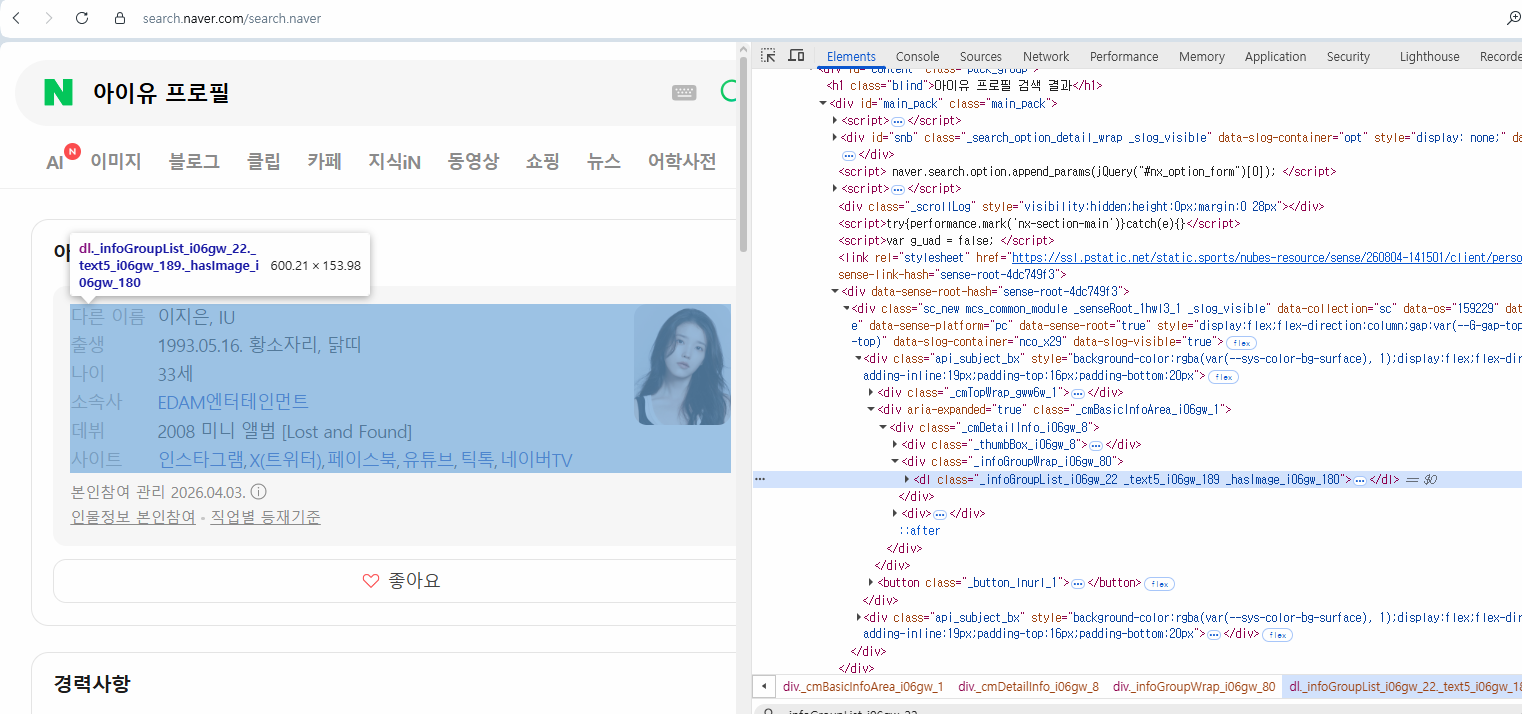</p>
<p>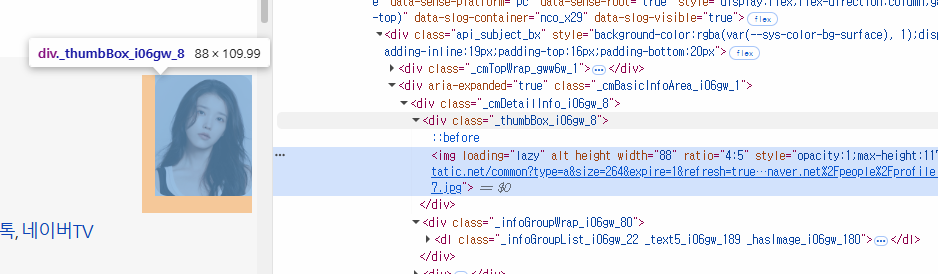</p>

In [99]:
#<풀이>
import requests
#아래의 url은 
url='https://search.naver.com/search.naver?where=nexearch&sm=tab_etc&mra=bjky&pkid=1&os=159229&qvt=0&query=%EC%95%84%EC%9D%B4%EC%9C%A0%20%ED%94%84%EB%A1%9C%ED%95%84'
url='https://search.naver.com/search.naver?query=아이유%20프로필'
res = requests.get(url)
soup = BeautifulSoup(res.text,'html.parser')
info_area = soup.find('dl', class_="_infoGroupList_i06gw_22")
info_area

<dl class="_infoGroupList_i06gw_22 _text5_i06gw_189 _hasImage_i06gw_180"><div class="_infoGroup_i06gw_22"><dt>다른 이름</dt><dd><span class="infoText"><span>이지은, IU</span></span></dd></div><div class="_infoGroup_i06gw_22"><dt>출생</dt><dd><span class="infoText"><span>1993.05.16.</span> </span><span class="infoText"><span>황소자리</span>, </span><span class="infoText"><span>닭띠</span></span></dd></div><div class="_infoGroup_i06gw_22"><dt>나이</dt><dd><span class="infoText"><span>33세</span></span></dd></div><div class="_infoGroup_i06gw_22"><dt>소속사</dt><dd><span class="_textWrapper_i06gw_229"><a class="_textLink_i06gw_233" href="?where=nexearch&amp;ssc=tab.nx.all&amp;sm=tab_clk.se&amp;qvt=0&amp;query=EDAM%EC%97%94%ED%84%B0%ED%85%8C%EC%9D%B8%EB%A8%BC%ED%8A%B8" nocr="1">EDAM엔터테인먼트</a></span></dd></div><div class="_infoGroup_i06gw_22"><dt>데뷔</dt><dd><span class="infoText"><span>2008 미니 앨범 [Lost and Found]</span></span></dd></div><div class="_infoGroup_i06gw_22"><dt>사이트</dt><dd><span class="_textWrapper_i

In [100]:
info_area.find_all('div', class_="_infoGroup_i06gw_22")[:3]

[<div class="_infoGroup_i06gw_22"><dt>다른 이름</dt><dd><span class="infoText"><span>이지은, IU</span></span></dd></div>,
 <div class="_infoGroup_i06gw_22"><dt>출생</dt><dd><span class="infoText"><span>1993.05.16.</span> </span><span class="infoText"><span>황소자리</span>, </span><span class="infoText"><span>닭띠</span></span></dd></div>,
 <div class="_infoGroup_i06gw_22"><dt>나이</dt><dd><span class="infoText"><span>33세</span></span></dd></div>]

In [101]:
info_dict = {}
for e in info_area.find_all('div', class_="_infoGroup_i06gw_22"):
    dt = e.find('dt')
    dd = e.find('dd')
    if dt and dd:
        print(f"{dt.text.strip()} : {dd.text.strip()}")
        key = dt.get_text(strip=True)
        info_dict[key] = dd.text.strip()

다른 이름 : 이지은, IU
출생 : 1993.05.16. 황소자리, 닭띠
나이 : 33세
소속사 : EDAM엔터테인먼트
데뷔 : 2008 미니 앨범 [Lost and Found]
사이트 : 인스타그램, X(트위터), 페이스북, 유튜브, 틱톡, 네이버TV


In [102]:
info_dict

{'다른 이름': '이지은, IU',
 '출생': '1993.05.16. 황소자리, 닭띠',
 '나이': '33세',
 '소속사': 'EDAM엔터테인먼트',
 '데뷔': '2008 미니 앨범 [Lost and Found]',
 '사이트': '인스타그램, X(트위터), 페이스북, 유튜브, 틱톡, 네이버TV'}

In [103]:
#find('div', class_='_thumbBox_i06gw_8') 이미지를 감싸는 박스        
img_box = soup.find('div', class_='_thumbBox_i06gw_8')
if img_box:
    #그 안에서 다시 find('img')를 하면 된다.
    img_tag = img_box.find('img')
    if img_tag and 'src' in img_tag.attrs:
        print("이미지 URL:", img_tag['src'])
        urlretrieve(img_tag['src'],'iu3.jpg')

이미지 URL: https://search.pstatic.net/common?type=a&size=264&expire=1&refresh=true&direct=true&quality=100&src=http%3A%2F%2Fsstatic.naver.net%2Fpeople%2FprofileImg%2Fb9e93747-149a-4cd8-bca5-ae0f830433e7.jpg


<h3 id="quote-:">quote :¶</h3>
파라미터로 입력시 url로 전송할때 인코딩
from urllib.parse import quote

In [104]:
from urllib.parse import quote, unquote
searchNamev = '카리나'
searchName = quote(searchNamev)
searchName

'%EC%B9%B4%EB%A6%AC%EB%82%98'

In [105]:
original = unquote(searchName)    # '%EC%...' => '카리나'
print("디코딩:", original)

디코딩: 카리나


In [106]:
def searchActor(sn):
    sn = quote(sn)
    url=f'https://search.naver.com/search.naver?query={sn}'
    res = requests.get(url)
    print(res.text[:1000])

In [110]:
snv = input("배우프로필 검색")
snv += snv+" 프로필"
searchActor(snv)

배우프로필 검색 ㄴㅇㄴㅊ


<!doctype html> <html lang="ko"><head> <meta charset="utf-8"> <meta name="referrer" content="strict-origin-when-cross-origin">  <meta name="format-detection" content="telephone=no,address=no,email=no"> <meta property="og:title" content="ㄴㅇㄴㅊㄴㅇㄴㅊ 프로필 : 네이버 검색"/> <meta property="og:image" content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png"> <meta property="og:description" content="'ㄴㅇㄴㅊㄴㅇㄴㅊ 프로필'의 네이버 검색 결과입니다."> <meta name="description" lang="ko" content="'ㄴㅇㄴㅊㄴㅇㄴㅊ 프로필'의 네이버 검색 결과입니다."> <title>ㄴㅇㄴㅊㄴㅇㄴㅊ 프로필 : 네이버 검색</title> <link rel="shortcut icon" href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_32x32_240820.ico">  <link rel="search" type="application/opensearchdescription+xml" href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" title="Naver" /><script>try{performance.mark('nx-head-start')}catch(e){}</script><link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/sstatic/search/pc/css/search1_260813.css?o=search"> <link r

In [111]:
def searchActor(name):
    q = quote(name)
    url = f'https://search.naver.com/search.naver?query={q}'
    res = requests.get(url)
    soup = BeautifulSoup(res.text, 'html.parser')
    info_area = soup.find('dl', class_="_infoGroupList_i06gw_22")
    if not info_area:
        print("인물정보 블록을 찾을 수 없습니다.")
    info_dict = {}
    for e in info_area.find_all('div', class_="_infoGroup_i06gw_22"):
        dt = e.find('dt')
        dd = e.find('dd')
        if dt and dd:
            key = dt.get_text(strip=True)
            print(f"{key} : {dd.text.strip()}")
            info_dict[key] = dd.text
    img_box = soup.find('div', class_="_thumbBox_i06gw_8")
    if img_box:
        img_tag = img_box.find('img')
        if img_tag and 'src' in img_tag.attrs:
            print("이미지 URL:", img_tag['src'])
    return info_dict
print(searchActor("아이유"))
print("*"*40)
searchActor("카리나")

출생 : 1993.05.16.
소속사 : EDAM엔터테인먼트
수상 : 제35회 골든디스크 어워즈 디지털음원부문 대상 외 128개 더보기
사이트 : 인스타그램, X(트위터), 페이스북, 유튜브, 틱톡, 네이버TV
이미지 URL: https://search.pstatic.net/common?type=a&size=264&expire=1&refresh=true&direct=true&quality=100&src=http%3A%2F%2Fsstatic.naver.net%2Fpeople%2FprofileImg%2Fb9e93747-149a-4cd8-bca5-ae0f830433e7.jpg
{'출생': '1993.05.16.', '소속사': 'EDAM엔터테인먼트', '수상': '제35회 골든디스크 어워즈 디지털음원부문 대상 외 128개 더보기', '사이트': '인스타그램, X(트위터), 페이스북, 유튜브, 틱톡, 네이버TV'}
****************************************
출생 : 2000.04.11.
소속그룹 : 에스파, 갓 더 비트
소속사 : SM엔터테인먼트
사이트 : 인스타그램, X(트위터), 페이스북, 유튜브, 웨이보
이미지 URL: https://search.pstatic.net/common?type=a&size=264&expire=1&refresh=true&direct=true&quality=100&src=http%3A%2F%2Fsstatic.naver.net%2Fpeople%2FprofileImg%2Ft%2F23009db5-cd33-485d-b79c-871a0de5d3ab.jpg


{'출생': '2000.04.11.',
 '소속그룹': '에스파, 갓 더 비트',
 '소속사': 'SM엔터테인먼트',
 '사이트': '인스타그램, X(트위터), 페이스북, 유튜브, 웨이보'}

<h3 id="select,-select_one">select, select_one¶</h3>
select : find_all()처럼 집합을 ResultSet으로 반환 , 선택자를 사용
select_one : find()처럼 하나의 요소를 반환 , 선택자를 사용

In [112]:
html4 = """
<html>
<body>
    <ul>
        <li><a href='http://naver.com' class='test'>naver</a></li>
        <li><a href='http://nate.com' class='test'>nate</a></li>
        <li><a href='http://google.com' class='test'>google</a></li>
        <li><a href='http://yahoo.com' class='test'>yahoo</a></li>
        <li><a href='http://daum.net' class='test'>다음</a></li>
    </ul>
    <a href='http://other.com' class='test'>other site</a>
</body>
</html>
"""
soup = BeautifulSoup(html4,'html.parser')

In [114]:
# select_one , 첫번째 요소를 가져온다.
first_a = soup.select_one('a')
print(f'{type(first_a)}: {first_a}')

<class 'bs4.element.Tag'>: <a class="test" href="http://naver.com">naver</a>


In [115]:
#find
first_aa = soup.find('a')
print(f'{type(first_aa)}: {first_aa}')

<class 'bs4.element.Tag'>: <a class="test" href="http://naver.com">naver</a>


In [116]:
#select : 선택자 
# a 태그에 클래스가 test 를 표현 : ul > li > a.test
#.test{ color:red} , a.test{ color:blue }
sel_links = soup.select('a.test')
sel_links

[<a class="test" href="http://naver.com">naver</a>,
 <a class="test" href="http://nate.com">nate</a>,
 <a class="test" href="http://google.com">google</a>,
 <a class="test" href="http://yahoo.com">yahoo</a>,
 <a class="test" href="http://daum.net">다음</a>,
 <a class="test" href="http://other.com">other site</a>]

In [117]:
# find_all
find_links = soup.find_all('a',{'class':'test'})
find_links

[<a class="test" href="http://naver.com">naver</a>,
 <a class="test" href="http://nate.com">nate</a>,
 <a class="test" href="http://google.com">google</a>,
 <a class="test" href="http://yahoo.com">yahoo</a>,
 <a class="test" href="http://daum.net">다음</a>,
 <a class="test" href="http://other.com">other site</a>]

In [118]:
"""
<한번해보기>
sel_links로 아래처럼 출력해보기

naver - http://naver.com
nate - http://nate.com
google - http://google.com
yahoo - http://yahoo.com
다음 - http://daum.net
other site - http://other.com
"""
#for 문사용해서 출력하면 끝
for link in sel_links:
    print(f"{link.get_text(strip=True)}-{link.attrs['href']}")
    print('*'*30)

naver-http://naver.com
******************************
nate-http://nate.com
******************************
google-http://google.com
******************************
yahoo-http://yahoo.com
******************************
다음-http://daum.net
******************************
other site-http://other.com
******************************


In [119]:
#select 를 사용해서 a href 속성의 값만 출력 - other는 불필요 하기 때문에 제거
all_links = soup.select('ul a[href]')
for link in all_links:
    print(link['href'])

http://naver.com
http://nate.com
http://google.com
http://yahoo.com
http://daum.net


In [120]:
#<한번해보기> 위의 select처럼  find_all로 추출해보기
ulTag = soup.find('ul')
all_links = ulTag.find_all('a',{'class':'test'})
all_links
for link in all_links:
    print(link['href'])

http://naver.com
http://nate.com
http://google.com
http://yahoo.com
http://daum.net
